In [ ]:
import matplotlib.pyplot as plt
import cv2 as cv
from lcLevy.Image import Img
from skimage.measure import ransac, LineModelND
import numpy as np

In [61]:
# Currently getting errors in this, but I will fix them later, trust

# uses lclevy cr3 file to extract a high definition jpeg from cr3 file - input a list of paths to convertible files
def parse_imgs(imgs):
    for img in imgs: 
        temp = Img(img, img[20:24])

# given the beginning number and end number of unconverted cr3 images, returns list of file paths 
def stage_imgs(range_begin, range_end):
    return [f"EOS_R100_Images/IMG_{"{:04d}".format(num)}.CR3" for num in range(range_begin, range_end)]

# Img("EOS_R100_Images/IMG_0006.CR3", "0006")

# parse_imgs(stage_imgs(7, 15))

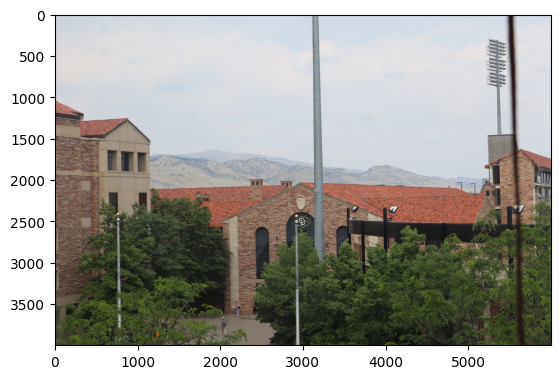

In [62]:
# Using image of folsom field as test image
image = cv.imread("EOS_R100_JPG/jpg0005.jpg")
image = image[:,:,::-1]
plt.imshow(image)

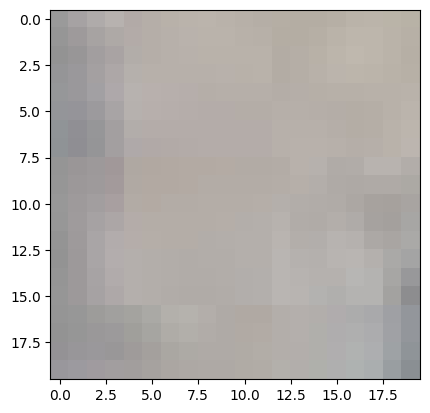

In [63]:
# take a patch of the image - eventually we will analyze all patches, but just want to calculate parameters for this patch right now
# What is the optimal patch size? Is it better to use larger ones or smaller ones?
patch_range = { 
    "minx":1500, 
    "maxx":1520, 
    "miny" : 2000, 
    "maxy": 2020,
    }
patch = image[patch_range["miny"]:patch_range["maxy"],patch_range["minx"]:patch_range["maxx"]]
plt.imshow(patch)

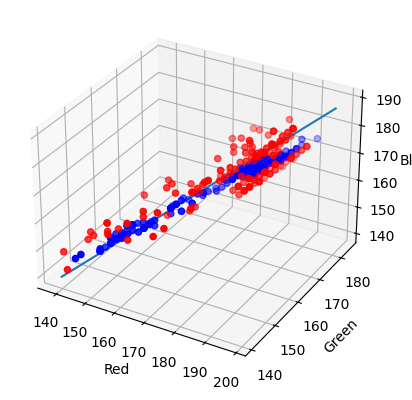

In [64]:
ax = plt.figure().add_subplot(projection = '3d')
ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue")

pixels = patch.reshape(400,3)

# for pix in pixels:
#     ax.scatter(pix[0], pix[1], pix[2], c = "darkblue")

zs = range(140, 190)
# ax.plot(xs, xs, xs)

# calculate the line of best fit (with ransac algorithm cos we want to use scikit for something)
# might be something to mess around with different options for later

lobf, inliers = ransac(pixels, LineModelND, 200, 2, max_trials = 1000)

outliers = inliers == False
ax.scatter(pixels[inliers][:, 0], pixels[inliers][:,1], pixels[inliers][:,2], c = "b")
ax.scatter(pixels[outliers][:, 0], pixels[outliers][:, 1], pixels[outliers][:,2], c = "r")

xs = lobf.predict_x(zs)
ys = lobf.predict_y(zs)
ax.plot(xs, ys, zs)
# print(lobf.)

plt.show()
    

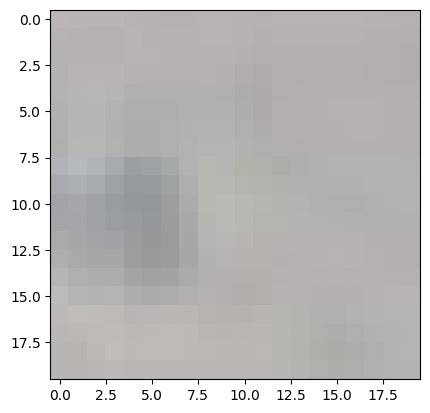

In [6]:
# Take a second patch, Analyze it as well
patch_two_range = { 
    "minx":2980, 
    "maxx":3000, 
    "miny" : 2000, 
    "maxy": 2020,
    }
patch_two = image[patch_two_range["miny"]:patch_two_range["maxy"],patch_two_range["minx"]:patch_two_range["maxx"]]
plt.imshow(patch_two)

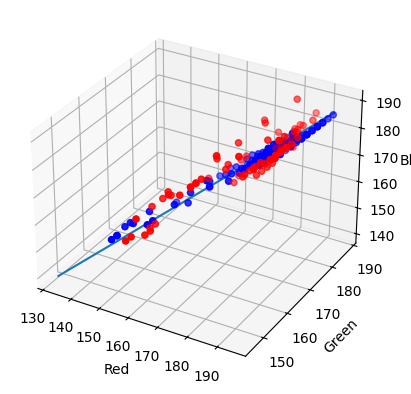

In [10]:
# This one looks like its fitting the data a lil funky
ax = plt.figure().add_subplot(projection = '3d')
ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue")

pixels = patch_two.reshape(400,3)

# for pix in pixels:
#     ax.scatter(pix[0], pix[1], pix[2], c = "darkblue")

zs = range(140, 190)
# ax.plot(xs, xs, xs)

# calculate the line of best fit (with ransac algorithm cos we want to use scikit for something)
# might be something to mess around with different options for later

lobf_two, inliers = ransac(pixels, LineModelND, 200, 2, max_trials = 1000)

outliers = inliers == False
ax.scatter(pixels[inliers][:, 0], pixels[inliers][:,1], pixels[inliers][:,2], c = "b")
ax.scatter(pixels[outliers][:, 0], pixels[outliers][:, 1], pixels[outliers][:,2], c = "r")

# Why are the x and y switched, this might cause errors...
xs = lobf_two.predict_x(zs)
ys = lobf_two.predict_y(zs)
ax.plot(xs, ys, zs)
# print(lobf.)

plt.show()

(Matrix([
[1, 0,  -1.00000000000001, -9.61591244169662e-13],
[0, 1, -0.999999999999988,  7.72849326727862e-13]]), (0, 1))
[114187.01684063 114187.01684063 114187.01684063]


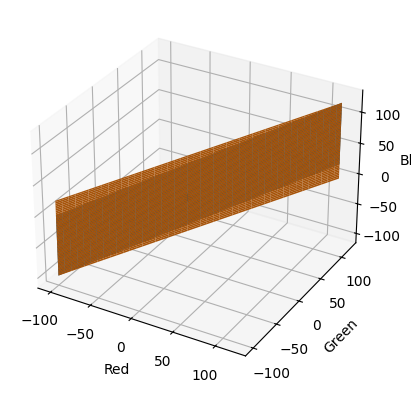

In [ ]:
# Plotting the intersection of the planes to find airlight direction vector
ax = plt.figure().add_subplot(projection = "3d")
ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue")

# plane 1
y1 = [50]
pt1 = [lobf.predict_x(y1)[0], lobf.predict_y(y1)[0], y1[0]]
y2 = [100]
pt2 = [lobf.predict_x(y2)[0],  lobf.predict_y(y2)[0], y2[0]]
n1 = np.cross(pt1, pt2)


xs = range(-100, 120)
ys = range(-100, 120)
zs = range(-100, 120)

# plot z points within plane
z1 = []
for x in range(len(xs)):
    z1.append([])
    for y in range(len(ys)):
        z1[x].append(pt2[2]-((n1[0]/n1[2])*(xs[x] - pt2[0]))-((n1[1]/n1[2])*(ys[y]-pt2[1])))
z1 = np.array(z1)
ax.plot_surface(xs, ys, z1)

# plane 2
pt3 =[lobf_two.predict_x(y1)[0],lobf_two.predict_y(y1)[0], y1[0]]
pt4 = [lobf_two.predict_x(y2)[0], lobf_two.predict_y(y2)[0], y2[0]]
n2 = np.cross(pt3, pt4)

# plot z points within plane two 
z2 = []
for y in range(len(ys)):
    z2.append([])
    for x in range(len(xs)):
        z2[y].append(pt3[2]-((n2[0]/n2[2])*(xs[x] - pt3[0]))-((n2[1]/n2[2])*(ys[y]-pt3[1])))
z2 = np.array(z2)
ax.plot_surface(xs, ys, z2)


# We're assuming that both planes pass through the origin, because they should I believe
# Should be the planes that go from the origin to these points
# Intersection will then be the cross product of their normal vectors, and going through the origin
intersect = np.cross(n1, n2)
print(intersect)

# xs = lobf_two.predict_x(zs)
# ys = lobf_two.predict_y(zs)
# ax.plot(xs, ys, zs)


plt.show()

In [42]:
# We have one of our necesary values!!
def normalize(vec):
    l = np.sqrt(vec[0]**2 + vec[1]**2+vec[2]**2)
    return [vec[0]/l, vec[1]/l, vec[2]/l]

A_hat = normalize(intersect)

# Length of vector from origin to line of best fit - in direction of A_hat probably
a_1 = np.sqrt(lobf.predict_x([0])**2 + lobf.predict_y([0])**2)[0]
a_2 = np.sqrt(lobf_two.predict_x([0])**2 + lobf_two.predict_y([0])**2)[0]

print(A_hat)
print(a_1)
print(a_2)

[np.float64(0.577350269189636), np.float64(0.5773502691896171), np.float64(0.5773502691896242)]
40.122640804509025
56.68698937697285


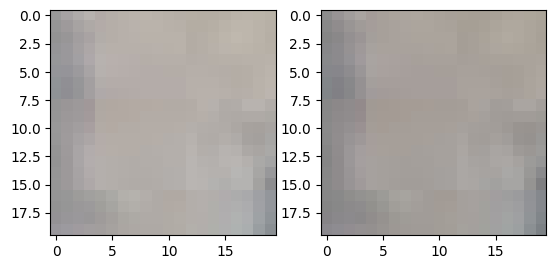

In [65]:
# Not sure I did the previous step right, but let's try applying the correction and see what happens
red_frac = A_hat[0]**2
green_frac = A_hat[1]**2
blue_frac = A_hat[2]**2

fig, ax = plt.subplots(1,2)
ax[0].imshow(patch)

for i in range(len(patch)):
    for j in range(len(patch[0])):
        patch[i][j][0]-= red_frac*a_1
        patch[i][j][1]-= green_frac*a_1
        patch[i][j][2] -= blue_frac*a_1


ax[1].imshow(patch)
